In [1]:
print("hello world")

hello world


In [2]:
import sys
sys.modules.pop('feature_transformer', None)
sys.modules.pop('utils.data_quality', None)
sys.modules.pop('utils.stats_dataset', None)
sys.modules.pop('utils.algo_prediction', None)
sys.modules.pop('utils.models_and_metrics', None)

In [3]:
from utils.feature_loader import load_feature_lists
from utils.data_quality import nettoyer_nan_par_colonne
# from utils.data_quality import nettoyer_lignes_vides
import pandas as pd
df_groh = pd.read_excel(r"C:\Users\romai\Desktop\travail\Copie de BAZEA.xlsx")
# taux de Nan
# for col in df_groh.columns:
#     print(round(df_groh[col].isna().mean(),2),col, )
# df_groh,index_a_drop = nettoyer_lignes_vides(df_groh)
feature_lists = load_feature_lists("utils/features_grroh.json",available_columns = df_groh.columns)
features_grroh = df_groh[feature_lists["Liste_features_grroh"] + feature_lists["Liste_features_scan_radio"]]
features_etiology = df_groh[feature_lists["features_etiology"]]
features_death = df_groh[feature_lists["death"]]
# print(features_grroh.columns)


In [4]:
from utils.data_quality import nettoyer_lignes_vides
from utils.feature_transformer import transform_features
sys.modules.pop('utils.utils_grroh',None)
from utils.utils_grroh import construire_mapping_renommage,format_to_efraim,ensure_float_clip
feature_lists = load_feature_lists("utils/features_grroh.json",available_columns = df_groh.columns)
# death
df_death = df_groh[feature_lists['death']]
df_death = df_death.copy()
df_death["death_days"] = (df_death['DATEDECES'] -  df_death['DSORTREA']).dt.days
df_death["death_rea"]  = df_death['death_days'] == 0 
df_death["death_90_days"]  = df_death["death_days"].notna() & (df_death["death_days"] > 90)

features_grroh = df_groh[feature_lists["Liste_features_grroh"] + feature_lists["Liste_features_scan_radio"]+ feature_lists["features_etiology"] ]
mapping_df = construire_mapping_renommage(feature_lists["Liste_features_grroh"] +feature_lists["Liste_features_scan_radio"] + feature_lists["features_etiology"] )
df_formatted = format_to_efraim(features_grroh, mapping_df)
df_renomme = ensure_float_clip(df_formatted)
df_nb = df_renomme.select_dtypes(include="number")
# _ = df_nb.hist(figsize=(10,8))
L_fill_mediane = ["Age"	,
                  "Time H-ICU"	,
                  "TIME SYMPTOMES-ICU",
                  "Time  DG-ICU",
                  "SOFA_score",
                  "Temp",
                  "Charlson_index",
                  "SaO2",
                  "PaO2/FiO2 VALUE VALUE",
                  "Resp_rate",
                  "Leukocytes",
                  "Quad_no"]
strategie_fill_nan = {
    col: "median" if col in L_fill_mediane else "zero"
    for col in df_renomme.columns
}
grroh_clean = nettoyer_nan_par_colonne(df_renomme,strategie_fill_nan)
grroh_clean["Hem_mal"]  = grroh_clean["Hem_mal"] .fillna(0)

grroh_clean_transform = transform_features(grroh_clean)#grroh_clean
grroh_clean_transform = grroh_clean_transform.drop(columns=['Leukocytes'])
# Enlever les non diag
L_diag = ['Bacterial infection', 'Viral infection',
'Invasive pulmonary aspergillosis', 'All fungus', 'Other fungal',
'Mucorales', 'Pneumocystis jirovecii infection',
'Cardiogenic pulmonary oedema', 'Disease-related infiltrates',
'Drug toxicity related', 'Other infection',
'Other non infectious causes']
L_features = [x for x in grroh_clean_transform if x not in L_diag]
grroh_diag = grroh_clean_transform[L_diag]

grroh_diag,index_a_drop = nettoyer_lignes_vides(grroh_diag)
grroh_clean_transform = grroh_clean_transform.drop(index=index_a_drop)
df_death = df_death.drop(index=index_a_drop)

grroh_features = grroh_clean_transform[L_features]
grroh_clean_transform = pd.concat([grroh_features,grroh_diag],axis=1)

🔹 Age → NaN remplacés par la médiane (63.0)
🔹 Time H-ICU → NaN remplacés par la médiane (6.0)
🔹 TIME SYMPTOMES-ICU → NaN remplacés par la médiane (1.0)
🔹 Time  DG-ICU → NaN remplacés par la médiane (199.0)
🔹 Charlson_index → NaN remplacés par la médiane (5.0)
🔹 SOFA_score → NaN remplacés par la médiane (6.0)
🔹 Resp_rate → NaN remplacés par la médiane (30.0)
🔹 SaO2 → NaN remplacés par la médiane (0.92)
🔹 Temp → NaN remplacés par la médiane (38.1)
🔹 Leukocytes → NaN remplacés par la médiane (8.2)
🔹 Quad_no → NaN remplacés par la médiane (2.0)
🔹 PaO2/FiO2 VALUE VALUE → NaN remplacés par la médiane (149.0)

✅ Nettoyage terminé. NaN restants : 0
Nombre de lignes totalement vides : 1106


c:\Users\romai\Desktop\codes\respiratory_diagnostics\utils\feature_transformer.py:192: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '1' has dtype incompatible with bool, please explicitly cast to a compatible dtype first.
  df.loc[df["GvHD"] >= 1,"GvHD"] = 1


In [5]:
len(grroh_features)

3032

In [15]:

# 

In [16]:
grroh_features["Indication_prophy_pneumocystose_taken"].value_counts()

Indication_prophy_pneumocystose_taken
0.0    1971
1.0     360
Name: count, dtype: Int64

In [23]:
sys.modules.pop('utils.stats_dataset')
from utils.stats_dataset import descript_data
df_outcome = pd.concat([grroh_features,df_death[["death_90_days","death_rea"]]],axis=1)
resume = descript_data(grroh_diag,non_binary_only=False,paper_format=True,save_path=r"C:\Users\romai\Desktop\travail\avancement\paper\grroh_diag_description.xlsx")


                            Variable Mediane [IQR] Donnees manquantes (%)  \
0                Bacterial infection   0.00 [1.00]                   0.00   
1                    Viral infection   0.00 [0.00]                   0.00   
2   Invasive pulmonary aspergillosis   0.00 [0.00]                   0.00   
3                         All fungus   0.00 [0.00]                   0.00   
4                       Other fungal   0.00 [0.00]                   0.00   
5                          Mucorales   0.00 [0.00]                   0.00   
6   Pneumocystis jirovecii infection   0.00 [0.00]                   0.00   
7       Cardiogenic pulmonary oedema   0.00 [0.00]                   0.00   
8        Disease-related infiltrates   0.00 [0.00]                   0.00   
9              Drug toxicity related   0.00 [0.00]                   0.00   
10                   Other infection   0.00 [0.00]                   0.00   
11       Other non infectious causes   0.00 [0.00]                   0.00   

In [ ]:
pd.unique(df_formatted["Excavation"].dropna())

array([0., 1., 2.])

Nombre de lignes contenant plus d'un '1' : 250

Distribution des valeurs positives (1) par colonne (% du total) :
Bacterial infection                 40.11
Viral infection                     12.60
Cardiogenic pulmonary oedema        12.01
Other non infectious causes         11.41
Disease-related infiltrates         10.19
Pneumocystis jirovecii infection     6.93
All fungus                           4.62
Invasive pulmonary aspergillosis     3.30
Drug toxicity related                3.20
Other infection                      2.70
Other fungal                         1.98
Mucorales                            0.10
dtype: float64


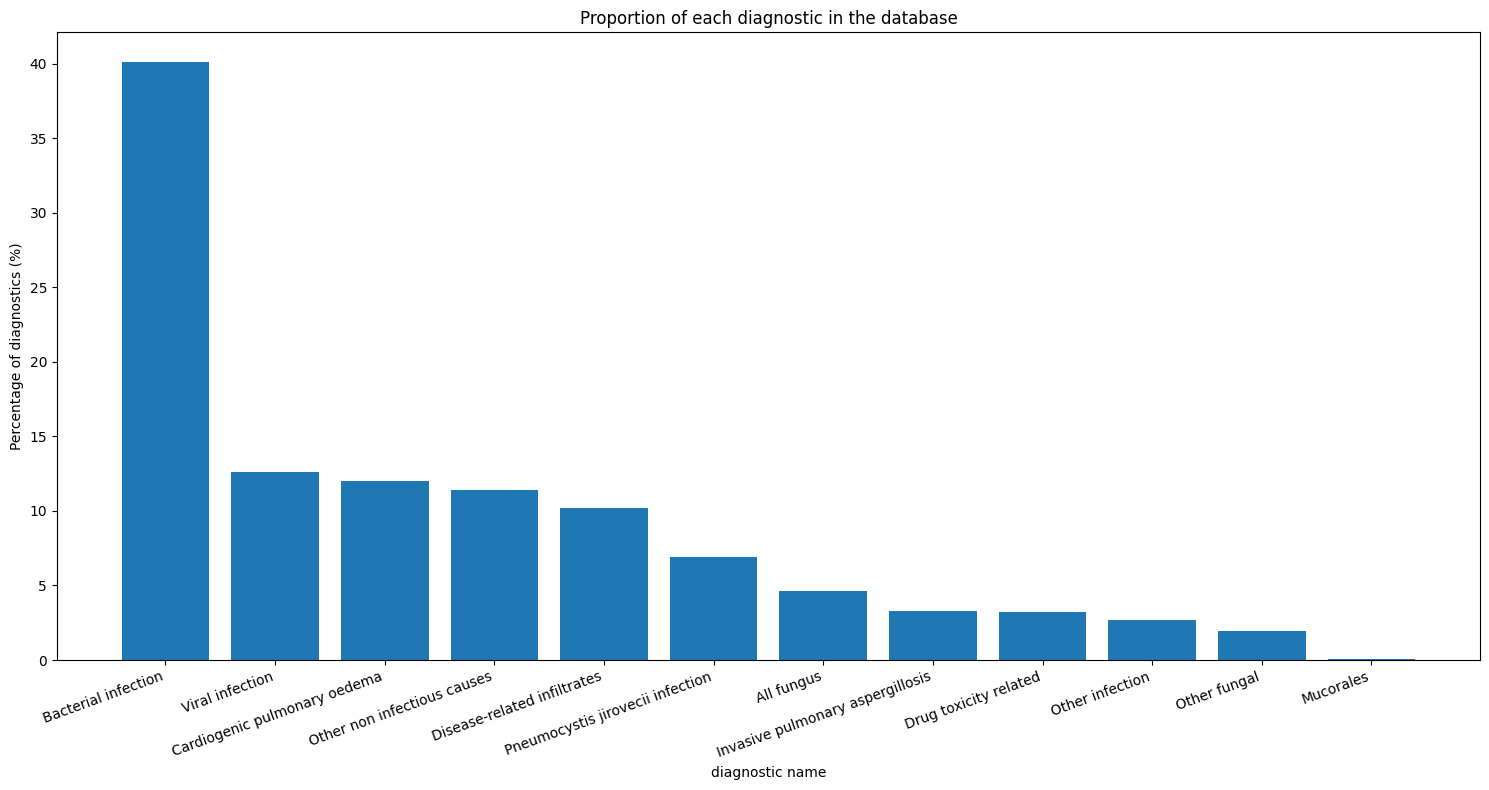

(<Figure size 1000x800 with 2 Axes>,
 <Axes: title={'center': 'Graph of codiagnostics'}>)

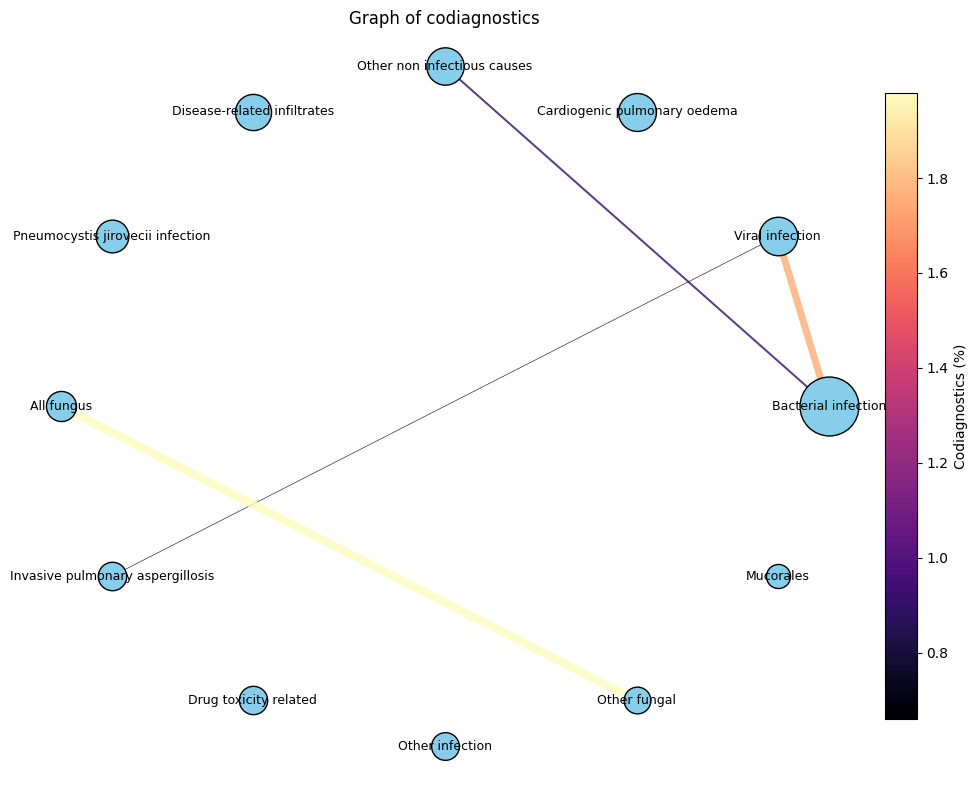

In [5]:
from utils.stats_dataset import analyser_variables_binaires
from utils.visualisation import plot_multilabel_network_matplotlib
analyser_variables_binaires(grroh_diag)
plot_multilabel_network_matplotlib(grroh_diag,normalize="percent",edge_threshold=0.5)

In [16]:
1106 - 159

947

In [12]:
grroh_diag.iloc[1876]

Bacterial infection                 False
Viral infection                      True
Invasive pulmonary aspergillosis     True
All fungus                          False
Other fungal                        False
Mucorales                           False
Pneumocystis jirovecii infection    False
Cardiogenic pulmonary oedema        False
Disease-related infiltrates         False
Drug toxicity related               False
Other infection                     False
Other non infectious causes         False
Name: 2589, dtype: bool

<Axes: >

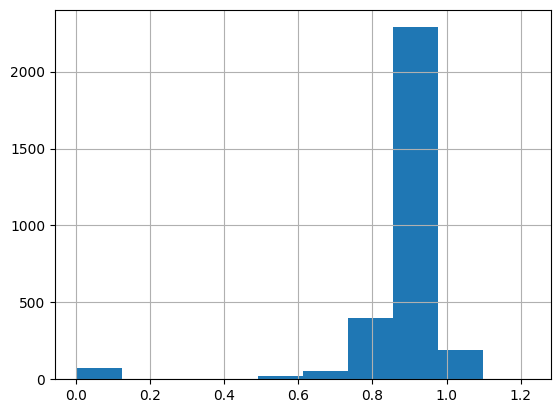

In [13]:
df_groh[df_groh["PAO2FIO2_meca"]>0]
df_float = ensure_float_clip(df_groh)
grroh_clean_transform["SaO2"].hist()

In [14]:
grroh_clean_transform
grroh_clean_transform[grroh_clean_transform["PaO2/FiO2 VALUE VALUE"]>0]

,Time H-ICU,TIME SYMPTOMES-ICU,Time DG-ICU,HSCT_BMT_Allograft,HSCT_BMT_Autograft,Sys_dis,Solid_tumor,Organ_transpl,Immuno_drugs,Steroids_YN,...,Invasive pulmonary aspergillosis,All fungus,Other fungal,Mucorales,Pneumocystis jirovecii infection,Cardiogenic pulmonary oedema,Disease-related infiltrates,Drug toxicity related,Other infection,Other non infectious causes
2,0.666667,0.000000,0.916667,0.0,0.0,0,0,0,False,1.0,...,False,False,False,False,False,False,False,False,False,True
3,0.000000,0.900000,0.000000,0.0,0.0,0,0,0,False,1.0,...,False,False,False,False,False,False,True,False,False,False
6,0.983051,0.000000,0.983051,0.0,0.0,0,0,0,False,1.0,...,False,True,False,False,False,False,False,False,False,False
7,0.000000,0.500000,0.997260,0.0,0.0,0,0,0,False,0.0,...,False,False,False,False,False,False,False,False,False,False
9,0.666667,0.000000,0.994764,0.0,0.0,0,0,0,False,0.0,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4121,0.916667,0.500000,0.916667,0.0,0.0,0,0,1,True,0.0,...,False,False,False,False,False,False,False,False,False,False
4122,0.500000,0.857143,0.997260,0.0,0.0,0,0,1,True,0.0,...,False,False,False,False,False,False,False,False,False,False
4123,0.916667,0.000000,0.997260,0.0,0.0,0,0,1,True,0.0,...,False,False,False,False,False,False,False,False,False,False
4128,0.000000,0.916667,0.997085,0.0,0.0,0,0,1,True,1.0,...,False,False,False,False,False,False,False,False,False,False


# Efraim 

In [6]:
import pandas as pd
import numpy as np
from pathlib import Path

import json
import matplotlib.pyplot as plt
from utils.stats_dataset import analyser_variables_binaires
from utils.feature_transformer import transform_features, _convert_all_columns_to_numeric
from utils.data_quality import nettoyer_nan_par_colonne
from utils.data_quality import analyser_nan,nettoyer_lignes_vides,nettoyer_colonnes
from utils.feature_loader import load_feature_lists, load_diagnostic_feature_map
import sys
# loads the col
FEATURE_CONFIG_PATH = "utils/feature_columns.json"
feature_lists = load_feature_lists(FEATURE_CONFIG_PATH)
Liste_features_simple = feature_lists["Liste_features_simple"]
features_radiology_dysfunction = feature_lists["features_radiology_dysfunction"]
features_etiology = feature_lists["features_etiology"]
features_death = feature_lists["death"]
# Charger le fichier Excel
df = pd.read_excel(r"C:\Users\romai\Desktop\travail\EFRAIM3 JD VANCE.xlsx")

# separer colonnes explicatives et etiology
df = df[df['Etiology_Undetermined cause_Definitive diagnosis'] != 1]
features_etiology.remove('Etiology_Undetermined cause_Definitive diagnosis')

diagnostic_feature_map = load_diagnostic_feature_map(
    FEATURE_CONFIG_PATH,
    available_columns=df.columns,
    diagnoses = ["default"] #"Bacterial infection", # A changer pour bacterial !!! 
)
all_feature_columns = []
for columns_list in diagnostic_feature_map.values():
    for feature_name in columns_list:
        if feature_name not in all_feature_columns:
            all_feature_columns.append(feature_name)
Liste_features = all_feature_columns
df_col_utils = df[Liste_features]
df_category = df[features_etiology]
df_death = df[features_death]
df_death = df_death[['icu death', 'D90 DEATH']].rename({'icu death' : "death_rea",'D90 DEATH' :  "death_90_days"}, axis=1)
DIAGNOSTIC_FEATURES = diagnostic_feature_map
L_fill_mediane = ["Age"	,"Time H-ICU"	,"TIME SYMPTOMES-ICU","SOFA_score",
                  "Neutrophils","Temp","SpO2","PaO2/FiO2 VALUE VALUE","Resp_rate","Leukocytes","Quad_no","Charlson_index"]
strategie_fill_nan = {
    col: "median" if col in L_fill_mediane else "zero"
    for col in Liste_features
}
strategie_fill_nan["DG1"] = "str"
strategie_fill_nan["DG2"] = "str"
strategie_fill_nan["Sys_dis_spec"] = "str"
df_col_utils = nettoyer_nan_par_colonne(df_col_utils,strategie_fill_nan)
df_features_clean = transform_features(df_col_utils)
# resultats = analyser_nan(df_col_utils, top_n=3)
# resultats_y = analyser_nan(df_category, top_n=8)
df_category = nettoyer_colonnes(df_category)
df_cat_clean,index_a_drop = nettoyer_lignes_vides(df_category)
df_features_clean = df_features_clean.drop(index=index_a_drop)
# df_features_clean = _convert_all_columns_to_numeric(df_features_clean)
# format mapping_etiology[nvelle_col] = [old_col1,old_cold2 ,...]
mapping_etiology ={
                    'Bacterial infection' :['Bacterial infection'] ,
                    'Viral infection' :['Viral infection'] ,
                    'Invasive pulmonary aspergillosis' :['Invasive pulmonary aspergillosis'] ,
                    'All fungus' : ["Other fungal ",'Mucorales'],
                    'Other fungal' :["Other fungal "] ,
                    'Mucorales' : ['Mucorales'],
                    'Pneumocystis jirovecii infection' :[ 'Pneumocystis jirovecii infection'],
                    'Cardiogenic pulmonary oedema' : ['Cardiogenic pulmonary oedema'],
                    'Disease-related infiltrates':['Disease-related infiltrates'],
                    'Drug toxicity related' : ['Drug toxicity related'],
                    'Other infection' : ['Other infection '],
                    'Other non infectious causes': ['Other non infectious causes','Transfusion-related acute lung injury'],
                   # 'Undetermined cause':['Undetermined cause' ]
                    }
from utils.data_quality import fusionner_labels
df_labels_fusion = fusionner_labels(df_cat_clean, mapping_etiology, mode="max")


🔹 Age → NaN remplacés par la médiane (64.0)
🔹 Time H-ICU → NaN remplacés par la médiane (2.0)
🔹 TIME SYMPTOMES-ICU → NaN remplacés par la médiane (2.0)
🔹 Charlson_index → NaN remplacés par la médiane (5.0)
🔹 SOFA_score → NaN remplacés par la médiane (7.0)
🔹 Resp_rate → NaN remplacés par la médiane (30.0)
🔹 SpO2 → NaN remplacés par la médiane (92.0)
🔹 Temp → NaN remplacés par la médiane (37.3)
🔹 PaO2/FiO2 VALUE VALUE → NaN remplacés par la médiane (88.0)
🔹 Neutrophils → NaN remplacés par la médiane (7.17)
🔹 Leukocytes → NaN remplacés par la médiane (9.51)
🔹 Quad_no → NaN remplacés par la médiane (3.0)
⚠️ Colonne 'DG1' absente du DataFrame, ignorée.
⚠️ Colonne 'DG2' absente du DataFrame, ignorée.
⚠️ Colonne 'Sys_dis_spec' absente du DataFrame, ignorée.

✅ Nettoyage terminé. NaN restants : 0
Nombre de lignes totalement vides : 3055


In [ ]:
df_death.columns

Index(['death_rea', 'death_90_days'], dtype='object')

In [21]:
sys.modules.pop('utils.stats_dataset')
from utils.stats_dataset import descript_data
df_outcome = pd.concat([df_features_clean,df_death],axis=1)
resume = descript_data(df_labels_fusion,non_binary_only=False,paper_format=True,save_path=r"C:\Users\romai\Desktop\travail\avancement\paper\efraim_labels_description.xlsx")


                            Variable Mediane [IQR] Donnees manquantes (%)  \
0                Bacterial infection   0.00 [1.00]                   0.00   
1                    Viral infection   0.00 [1.00]                   0.00   
2   Invasive pulmonary aspergillosis   0.00 [0.00]                   0.00   
3                         All fungus   0.00 [0.00]                   0.00   
4                       Other fungal   0.00 [0.00]                   0.00   
5                          Mucorales   0.00 [0.00]                   0.00   
6   Pneumocystis jirovecii infection   0.00 [0.00]                   0.00   
7       Cardiogenic pulmonary oedema   0.00 [0.00]                   0.00   
8        Disease-related infiltrates   0.00 [0.00]                   0.00   
9              Drug toxicity related   0.00 [0.00]                   0.00   
10                   Other infection   0.00 [0.00]                   0.00   
11       Other non infectious causes   0.00 [1.00]                   0.00   

# Comparasion des valeurs 

In [17]:
df_groh['age'].max()

np.float64(94.0)

In [18]:
sys.modules.pop('utils.data_quality',None)
from utils.data_quality import compare_columns
df_with_diag = pd.concat([df_features_clean,df_labels_fusion],axis=1)

compare_columns(df_with_diag,grroh_clean_transform)

Colonnes uniquement dans df1 :
set()

Colonnes uniquement dans df2 :
set()


[HSCT_BMT_Allograft] variable binaire ignoree (|Delta| < 5.0 pts)
[HSCT_BMT_Autograft] variable binaire ignoree (|Delta| < 5.0 pts)
[Sys_dis] difference d'occurrence >= 5.0 pts
    valeur=np.int64(0): 5239/6360 (82.37%) vs 2781/3032 (91.72%) -> diff -9.35 pts (10.2% de la valeur max 91.72%)
    valeur=np.int64(1): 1121/6360 (17.63%) vs 251/3032 (8.28%) -> diff +9.35 pts (53.0% de la valeur max 17.63%)
[Solid_tumor] difference d'occurrence >= 5.0 pts
    valeur=np.int64(0): 3950/6360 (62.11%) vs 2179/3032 (71.87%) -> diff -9.76 pts (13.6% de la valeur max 71.87%)
    valeur=np.int64(1): 2410/6360 (37.89%) vs 853/3032 (28.13%) -> diff +9.76 pts (25.8% de la valeur max 37.89%)
[Organ_transpl] variable binaire ignoree (|Delta| < 5.0 pts)
[Immuno_drugs] difference d'occurrence >= 5.0 pts
    valeur=np.int64(0): 3886/6360 (61.10%) vs 2363/3032 (77.94%) -> diff -16.83 pts (21.6% de la valeur max 77.94%)
    valeur=np.int64(1): 2474/6360 (38.90%) vs 669/3032 (22.06%) -> diff +16.83 pts (43.3% 

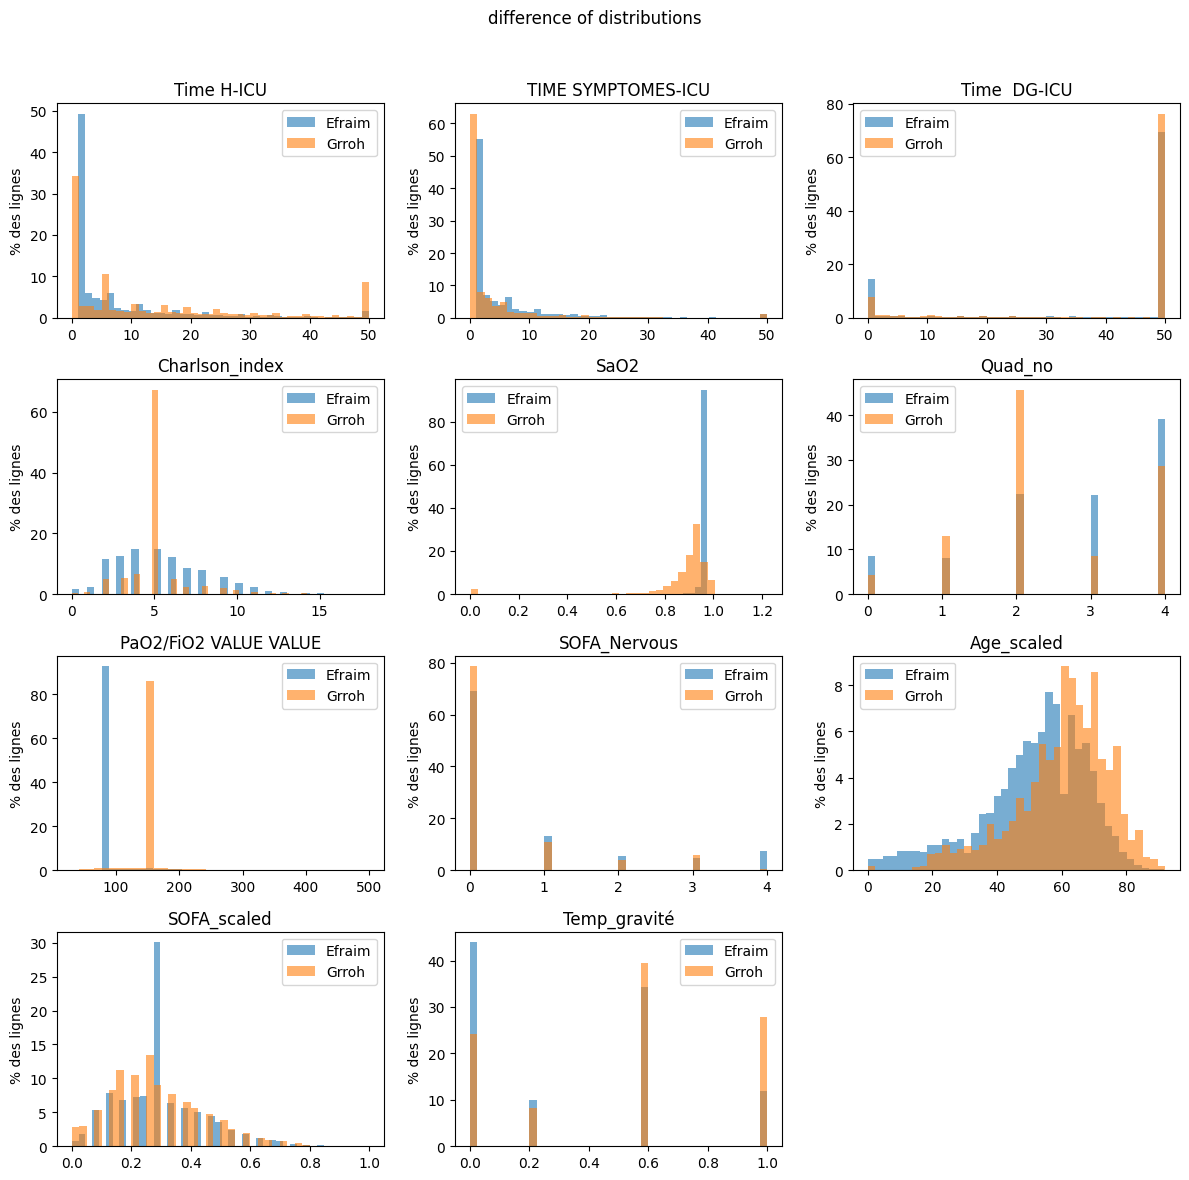

In [19]:
sys.modules.pop("utils.data_quality",None)
from utils.data_quality import plot_column_histograms

fig, axes = plot_column_histograms(
    df_left=df_with_diag,
    df_right=grroh_clean_transform,
    columns=grroh_clean_transform.columns,
    bins=40,
    label_left="Efraim",
    label_right="Grroh",
    suptitle="difference of distributions"
)
plt.show()

# performance sur les données du grroh

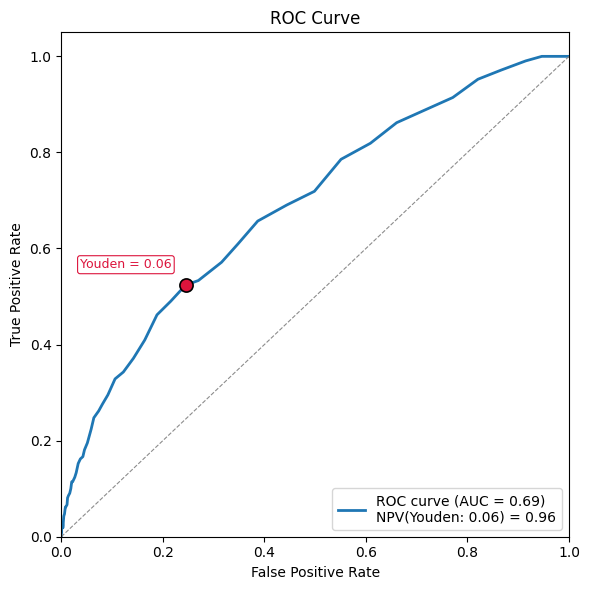

ROC AUC = 0.69
Negative Predictive Value youden: 0.9538793103448275 threshold 0.06333333333333334


KeyboardInterrupt: 

In [7]:
from utils.model_saving import save_model, load_model
from utils.validation import validation_save
import os 
diagnostique = 'Pneumocystis jirovecii infection'
save_dir = r"C:\Users\romai\Desktop\travail\avancement\model_grid_search\\"
# for diagnostique in grroh_diag.columns:
model_loaded = load_model(diagnostic =diagnostique,
                    model_dir = os.getcwd() + r'\models\\'
                    )
# print(model_loaded["pipe_inference"].named_steps["scaler"].colonnes_numeriques)
validation_save(diagnostique,
                    save_dir,
                    
                    loaded = model_loaded,
                    grroh_features = grroh_features,
                    grroh_diag = grroh_diag,
                    df_features_clean = df_features_clean,
                    df_labels_fusion = df_labels_fusion
                    )


In [37]:
y_test.shape

(3032,)

In [95]:
for x in df_groh["DIAGPRINCIPAL_final.recod"].value_counts().index:
    try:
        float(x) 
        
    except:
        print(x)

BACT
BACT DOCU
UNDETERMINED
bact
EXTRA
UNKNOWN
infiltratif
BACT CLI
INFLUENZA
PCP
OAP
extra
INFILTRATIF
unknown
oap
aspiration
VIRUS
candidemie
AIRWAYS
airways
ASPIRATION
pcp
PLEURA
tox
pleura
TOX
IPA
influenza
ipa
copd
AUTRE
API
vrs
EP
pe
DRPT
VRS
RHINOVIRUS
PE
CMV
COPD
METAPNEUMOVIRUS
CORONAVIRUS
cmv
PIV3
parasite
ADENOVIRUS
bk
TRICHOSPORON
piv3
BACT DOCU + CAND
ENTEROVIRUS
MUCOR
NEUT RECOV
HSV
INFLuenza
coronavirus
rhinovirus
trichosporon


# Graphique de nom de maladie du sang

NameError: name 'plt' is not defined

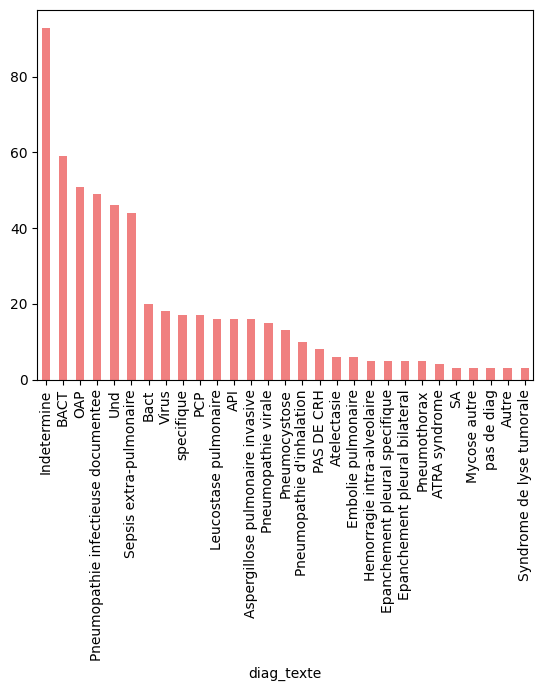

In [ ]:
df["diag_texte"].value_counts()[1:30].plot(kind='bar', color='lightcoral')
import matplotlib.pyplot as plt
plt.title("Distribution des diagnostiques")
plt.xlabel("diagnostiques")
plt.ylabel("Occurence")
plt.xticks(rotation=45, ha='right')
plt.show()